# 3 · Tidal feasibility — site exploration

### Before you map: how well do your satellites sample the tidal cycle?

Intertidal elevation mapping needs satellite images taken at **many different tide
heights**. If your satellites only pass at mid-tide, you cannot reliably separate wet
from dry flats — the algorithm needs observations near **high** and **low** water.

This notebook answers three questions for your site:

1. What is the **tidal range** here (FES2022)?
2. When do **Landsat** and/or **Sentinel-2** actually overpass, and at what tide height?
3. Does that sampling **cover the tidal cycle** well enough for mapping?

**How to read the results**

| Metric / plot | Meaning |
|---|---|
| **HAT / LAT** | Highest / lowest astronomical tide in the model period (FES2022) |
| **HOT / LOT** | Highest / lowest tide height at which a *clear* satellite scene was acquired |
| **HAT offset** | Gap between HAT and HOT — high water never observed by satellites |
| **LAT offset** | Gap between LAT and LOT — low water never observed |
| **TOT** (`spread`) | Fraction of the full tidal range sampled by satellites (1.0 = perfect) |
| **HOT / LOT** (stats table) | Coverage score near high / low water (1.0 = well sampled) |

Rule of thumb before running page 6 (elevation mapping):

- **TOT ≥ 0.8** — good range coverage
- **HOT & LOT ≥ 0.5** — acceptable high/low sampling
- **≥ 20 clear scenes** per sensor — stable fit (more is better)

**Previous:** [2 · Connect](02_connect.ipynb) · **Next:** [4 · Validation](04_validation.ipynb)


## Step 1 — Imports

We load the libraries used in this notebook. In short:

| Import | Role in this notebook |
|---|---|
| `numpy` / `pandas` | Tables of scenes, tide series, statistics |
| `matplotlib` | All plots (tide curve, scene timing, offsets) |
| `matplotlib.dates` | Readable date axes |
| `Path` | Locate the `cache/` folder and tide model files |
| `cache_utils` | **Our helpers** — tide series, scene query, coverage stats (see end of notebook) |
| `eo_tides.stats` | Used inside `tidal_coverage_stats` (Bishop-Taylor metrics) |

The expensive steps (FES2022 + Planetary Computer) run inside `cache_utils`, not here.


In [1]:
import sys
assert sys.version_info >= (3, 12), f"Python >= 3.12 required (have {sys.version.split()[0]})"

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from cache_utils import load_or_compute_tides, load_or_compute_scenes, tidal_coverage_stats

warnings.filterwarnings("ignore")
print("Imports OK.")

Imports OK.


## Step 2 — Site configuration and sensor selection

Edit the coordinates, time window, and **which satellites to include**.

| Sensor | Revisit | Resolution | Notes |
|---|---|---|---|
| **Sentinel-2** | ~5 days | 10 m | Denser sampling; data from 2015 |
| **Landsat 8 / 9** | ~16 days each | 30 m | Long archive; two platforms ≈ 8-day combined |

Set `OVERWRITE = True` once after changing location, dates, or sensor selection — this
rebuilds the cache. Set back to `False` for faster re-runs.

`MAX_CLOUD` filters scenes with more than this cloud cover (%) both in the STAC query
and in the analysis below.


In [3]:
# === EDIT THESE ===
LON        = 4.81050
LAT        = 52.98886
SITE_NAME  = "WaddenSea"

TIDE_DIR   = "./tide_models"
TIDE_MODEL = "FES2022"

START = "2023-01-01"
END   = "2023-12-31"

# --- Sensor selection (toggle on/off) ---
USE_SENTINEL2 = False
USE_LANDSAT8  = True
USE_LANDSAT9  = True

MAX_CLOUD = 80          # exclude scenes with cloud cover ≥ this value (%)
OVERWRITE = False       # set True once after changing site / dates / sensors

# Build sensor list passed to Planetary Computer
SENSORS = [name for name, use in [
    ("Sentinel-2", USE_SENTINEL2),
    ("Landsat 8",  USE_LANDSAT8),
    ("Landsat 9",  USE_LANDSAT9),
] if use]
if not SENSORS:
    raise ValueError("Enable at least one sensor (Sentinel-2 and/or Landsat).")

# -------------------------------------------------------
os.environ["EO_TIDES_TIDE_MODELS"] = TIDE_DIR
print(f"Site: {SITE_NAME}  ({LAT:.4f} N, {LON:.4f} E)")
print(f"Window: {START} to {END}")
print(f"Sensors: {', '.join(SENSORS)}  |  max cloud: {MAX_CLOUD}%")


Site: WaddenSea  (52.9889 N, 4.8105 E)
Window: 2023-01-01 to 2023-12-31
Sensors: Landsat 8, Landsat 9  |  max cloud: 80%


## Step 3 — Tidal range (FES2022)

`load_or_compute_tides` runs FES2022 at **30-minute intervals** for your site (or loads
from cache). This is the **full astronomical tide signal** — what satellites *should*
sample if they passed at all tide phases equally.

The plot shows a 3-month excerpt plus the **distribution** over the full period:

- **HAT** — highest astronomical tide
- **LAT** — lowest astronomical tide
- **MSL** — mean sea level (average tide height)
- **MHWS / MLWS** — mean higher / lower water (90th / 10th percentile)

These reference lines reappear in later steps when we compare against satellite passes.


In [4]:
heights = load_or_compute_tides(
    lon=LON, lat=LAT,
    start=START, end=END,
    site_name=SITE_NAME,
    tide_model=TIDE_MODEL,
    tide_dir=TIDE_DIR,
    overwrite=OVERWRITE,
)

hat  = heights.max()
lat_ = heights.min()
mean = heights.mean()
mhws = heights.quantile(0.90)
mlws = heights.quantile(0.10)

print(f"\nTidal range at {SITE_NAME}")
print(f"  HAT  : {hat:+.3f} m    LAT  : {lat_:+.3f} m")
print(f"  MHWS : {mhws:+.3f} m    MLWS : {mlws:+.3f} m")
print(f"  MSL  : {mean:+.3f} m    Range: {hat-lat_:.3f} m")

  Loaded from cache ← cache/tides_WaddenSea_2023-01-01_2023-12-31.parquet  (17,473 rows)

Tidal range at WaddenSea
  HAT  : +1.154 m    LAT  : -1.167 m
  MHWS : +0.669 m    MLWS : -0.747 m
  MSL  : +0.001 m    Range: 2.321 m


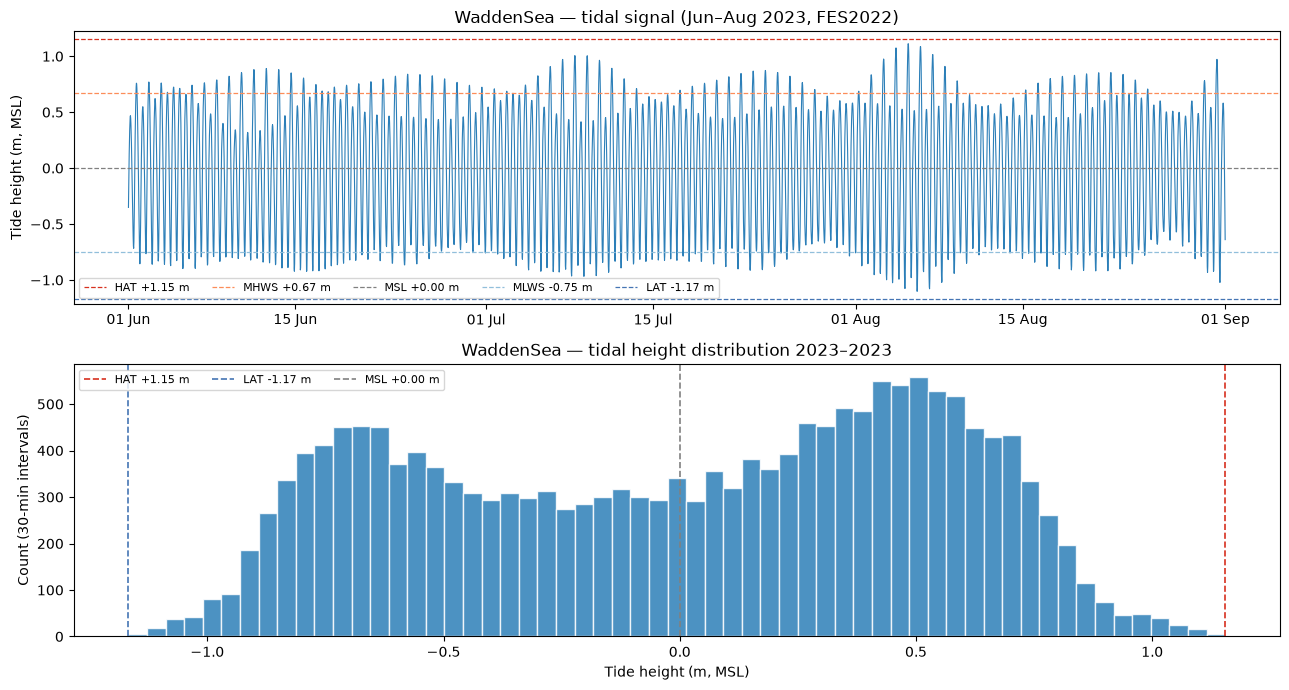

In [5]:
# Plot: 90-day excerpt + full histogram
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))

sample = heights.loc["2023-06-01":"2023-08-31"]
ax1.plot(sample.index, sample.values, lw=0.8, color="#2c7fb8")
for val, col, lbl in [(hat, "#d7301f", "HAT"), (mhws, "#fc8d59", "MHWS"),
                      (mean, "grey", "MSL"), (mlws, "#91bfdb", "MLWS"),
                      (lat_, "#4575b4", "LAT")]:
    ax1.axhline(val, ls="--", lw=0.9, color=col, label=f"{lbl} {val:+.2f} m")
ax1.set_ylabel("Tide height (m, MSL)")
ax1.set_title(f"{SITE_NAME} — tidal signal (Jun–Aug 2023, FES2022)")
ax1.legend(fontsize=8, ncol=5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

bins = np.linspace(lat_, hat, 60)
ax2.hist(heights.values, bins=bins, color="#2c7fb8", edgecolor="white", alpha=0.85)
for val, col, lbl in [(hat, "#d7301f", "HAT"), (lat_, "#4575b4", "LAT"),
                      (mean, "grey", "MSL")]:
    ax2.axvline(val, color=col, lw=1.2, ls="--", label=f"{lbl} {val:+.2f} m")
ax2.set_xlabel("Tide height (m, MSL)")
ax2.set_ylabel("Count (30-min intervals)")
ax2.set_title(f"{SITE_NAME} — tidal height distribution {START[:4]}–{END[:4]}")
ax2.legend(fontsize=8, ncol=3)

fig.tight_layout()
plt.show()

### Interpreting Step 3

The grey histogram counts how often each tide height occurs in the model (every 30 min).
Satellites do **not** sample this uniformly — sun-synchronous orbits can miss parts of
the cycle (tide aliasing). Steps 4–6 show how your actual scene dates compare to this
full signal.


## Step 4 — Satellite scenes + tide tags

`load_or_compute_scenes` queries **Planetary Computer** for scene metadata only (no
pixels downloaded), then tags each acquisition time with the nearest FES2022 height.

Only the sensors you enabled in Step 2 are queried. The result is cached per sensor
combination — change `USE_SENTINEL2` / `USE_LANDSAT*` and set `OVERWRITE = True` to
refresh.

> **Note:** Scene counts depend on cloud cover, revisit rate, and footprint. Sentinel-2
> typically yields many more scenes than a single Landsat platform.


In [6]:
scenes_df = load_or_compute_scenes(
    lon=LON, lat=LAT,
    start=START, end=END,
    site_name=SITE_NAME,
    tide_model=TIDE_MODEL,
    tide_dir=TIDE_DIR,
    max_cloud=MAX_CLOUD,
    sensors=SENSORS,
    overwrite=OVERWRITE,
)

if "time" not in scenes_df.columns:
    scenes_df = scenes_df.reset_index()

print(f"\nScene counts at {SITE_NAME} (cloud < {MAX_CLOUD}% in STAC query)")
if scenes_df.empty:
    print("  No scenes found — widen dates, raise MAX_CLOUD, or check coordinates.")
else:
    print(scenes_df.groupby("sensor").size().rename("total").to_frame().to_string())
    missing = set(SENSORS) - set(scenes_df["sensor"].unique())
    if missing:
        print(f"\n  No scenes for: {', '.join(sorted(missing))}")
        print("  (Can be normal for short windows or strict cloud limits.)")


  Querying PC for Landsat 8 ...
  Querying PC for Landsat 9 ...
  Loaded from cache ← cache/tides_WaddenSea_2023-01-01_2023-12-31.parquet  (17,473 rows)
  Tagged 55/55 scenes with tide heights (±30 min)
  Cached → cache/scenes_WaddenSea_l8-l9_2023-01-01_2023-12-31.parquet  (55 rows)

Scene counts at WaddenSea (cloud < 80% in STAC query)
           total
sensor          
Landsat 8     29
Landsat 9     26


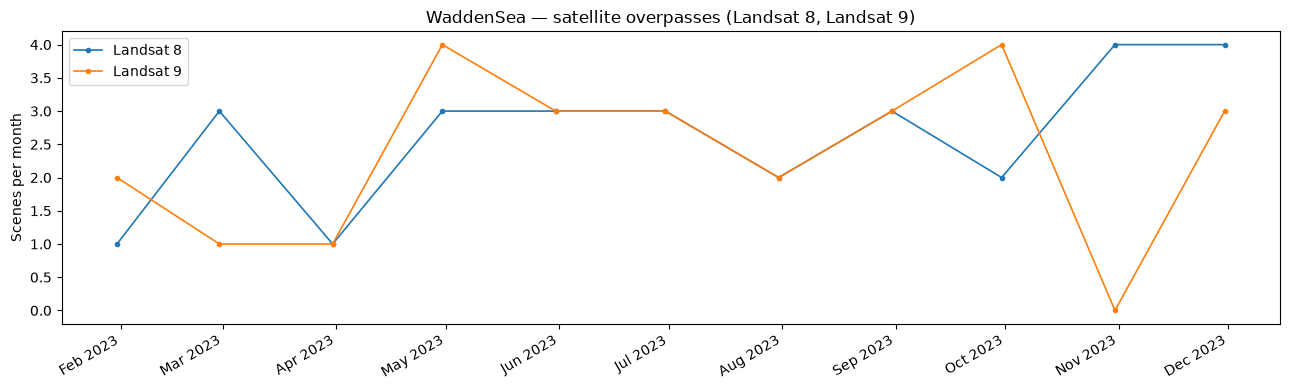

In [7]:
# Scenes per month — check revisit density per sensor
colors = {"Sentinel-2": "#2ca02c", "Landsat 8": "#1f77b4", "Landsat 9": "#ff7f0e"}

fig, ax = plt.subplots(figsize=(13, 4))
if scenes_df.empty:
    ax.text(0.5, 0.5, "No scenes — adjust sensors, dates, or MAX_CLOUD",
            ha="center", va="center", transform=ax.transAxes)
else:
    for sensor, grp in scenes_df.groupby("sensor"):
        monthly = grp.set_index("time").resample("ME").size()
        ax.plot(monthly.index, monthly.values, marker="o", ms=3, lw=1.2,
                label=sensor, color=colors.get(sensor, "grey"))
    ax.legend()
ax.set_ylabel("Scenes per month")
ax.set_title(f"{SITE_NAME} — satellite overpasses ({', '.join(SENSORS)})")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
plt.show()


### Interpreting Step 4

- **Flat or sparse lines** — few usable scenes; extend `START`/`END` or enable more sensors.
- **Only Landsat visible** — check that `USE_SENTINEL2 = True` and `OVERWRITE = True`
  after changing sensors (old cache may exclude Sentinel-2).
- **Gaps in months** — normal for Landsat (~2 passes/month); Sentinel-2 fills gaps if enabled.


## Step 5 — Tidal coverage statistics

Compares tide heights **observed by clear satellite scenes** against the **full FES2022
signal** (Bishop-Taylor et al. 2019).

| Column | Meaning | Good value |
|---|---|---|
| `observed_count` | Number of clear scenes used | ≥ 20 |
| `observed_range` | Tide range actually sampled (m) | close to full range |
| `tot` / `spread` | Fraction of HAT–LAT range sampled | ≥ 0.8 |
| `hot` | High-tide coverage (1 − HAT offset fraction) | ≥ 0.5 |
| `lot` | Low-tide coverage (1 − LAT offset fraction) | ≥ 0.5 |


In [8]:
from cache_utils import tidal_coverage_stats

clear_mask = scenes_df["cloud_cover"].fillna(100) < MAX_CLOUD
MIN_CLEAR = 3

stats_rows = []
for sensor in scenes_df["sensor"].unique():
    mask = (scenes_df["sensor"] == sensor) & clear_mask
    sub = scenes_df.loc[mask, "tide_height"].dropna()
    stats = tidal_coverage_stats(sub.values, heights.values, min_observations=MIN_CLEAR)
    if stats is None:
        print(f"  {sensor}: only {len(sub)} clear scene(s) (need ≥{MIN_CLEAR}) — skipping")
        continue
    stats_rows.append({"sensor": sensor, **stats})

all_clear = scenes_df.loc[clear_mask, "tide_height"].dropna()
combined = tidal_coverage_stats(all_clear.values, heights.values, min_observations=MIN_CLEAR)
if combined is not None:
    stats_rows.append({"sensor": "ALL (combined)", **combined})

if not stats_rows:
    raise ValueError(
        f"No tidal coverage stats — fewer than {MIN_CLEAR} clear scenes. "
        f"Enable more sensors, extend START/END, or raise MAX_CLOUD (now {MAX_CLOUD}%)."
    )

stats_df = pd.DataFrame(stats_rows).set_index("sensor")
cols = [c for c in ["observed_count", "observed_range", "tot", "hot", "lot", "spread"]
        if c in stats_df.columns]
print(f"\nTidal coverage statistics — {SITE_NAME}")
print(stats_df[cols].round(3).to_string())



Tidal coverage statistics — WaddenSea
                observed_count  observed_range    tot    hot    lot  spread
sensor                                                                     
Landsat 8                   29           1.827  0.787  0.936  0.851   0.787
Landsat 9                   26           1.791  0.771  0.909  0.862   0.771
ALL (combined)              55           1.853  0.798  0.936  0.862   0.798


## Step 6 — Visualise sampling and HAT/LAT offsets

The grey curve is the **full FES2022 tide**. Coloured dots are **clear satellite
acquisitions** at the tide height predicted for that moment.

- **Red dashed (HAT)** — highest modelled tide in the period
- **Blue dashed (LAT)** — lowest modelled tide
- **Red dotted (HOT)** — highest tide at which a satellite actually passed
- **Blue dotted (LOT)** — lowest tide at which a satellite actually passed
- **Shaded bands** — offset gaps: tide range never observed near high / low water

Large HAT offset → satellites miss extreme high tides (upper flats may be undersampled).
Large LAT offset → low-water flats rarely seen dry.


Highest satellite observation (HOT): +1.006 m
Lowest satellite observation  (LOT): -0.847 m
Offset HAT → HOT: 0.149 m  (6.4% of tidal range)
Offset LAT → LOT: 0.319 m  (13.8% of tidal range)


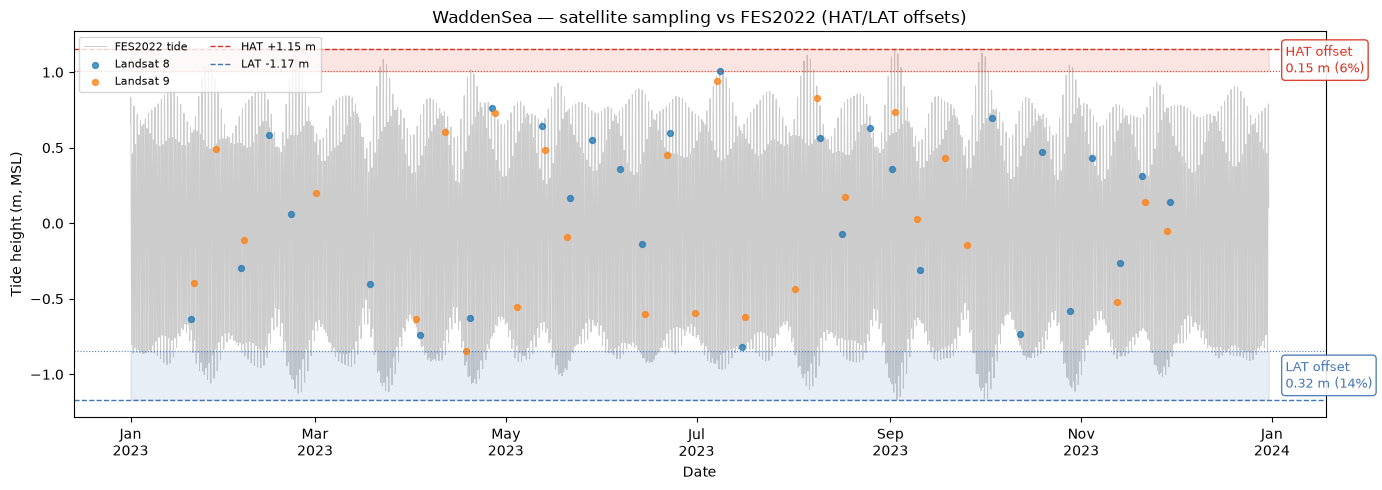

In [10]:
if "time" not in scenes_df.columns:
    scenes_df = scenes_df.reset_index()

clear_mask = scenes_df["cloud_cover"].fillna(100) < MAX_CLOUD

obs = scenes_df.loc[clear_mask, "tide_height"].dropna()
if len(obs) < 1:
    raise ValueError("No clear scenes with tide heights — check Step 4.")

hot = float(obs.max())   # highest tide at a satellite pass
lot = float(obs.min())   # lowest tide at a satellite pass
tr = float(hat - lat_)

offset_high_m = hat - hot          # HAT minus highest observation
offset_low_m = lot - lat_          # lowest observation minus LAT
offset_high_pct = offset_high_m / tr if tr > 0 else float("nan")
offset_low_pct = offset_low_m / tr if tr > 0 else float("nan")

print(f"Highest satellite observation (HOT): {hot:+.3f} m")
print(f"Lowest satellite observation  (LOT): {lot:+.3f} m")
print(f"Offset HAT → HOT: {offset_high_m:.3f} m  ({offset_high_pct:.1%} of tidal range)")
print(f"Offset LAT → LOT: {offset_low_m:.3f} m  ({offset_low_pct:.1%} of tidal range)")

fig, ax = plt.subplots(figsize=(14, 5))

tide_ts = heights.copy()
tide_ts.index = pd.to_datetime(tide_ts.index, utc=True)
ax.plot(tide_ts.index, tide_ts.values, color="#cccccc", lw=0.7, zorder=0,
        label="FES2022 tide")

for sensor in scenes_df["sensor"].unique():
    sub = scenes_df.loc[(scenes_df["sensor"] == sensor) & clear_mask]
    ax.scatter(sub["time"], sub["tide_height"], s=18, alpha=0.75,
               label=sensor, color=colors.get(sensor, "grey"), zorder=2)

ax.axhline(hat, color="#d7301f", lw=1.0, ls="--", label=f"HAT {hat:+.2f} m")
ax.axhline(lat_, color="#4575b4", lw=1.0, ls="--", label=f"LAT {lat_:+.2f} m")
ax.axhline(hot, color="#d7301f", lw=0.8, ls=":", alpha=0.9)
ax.axhline(lot, color="#4575b4", lw=0.8, ls=":", alpha=0.9)

# Offset bands + labels (right edge of plot)
x_annot = tide_ts.index.max()
for y0, y1, col, txt in [
    (hot, hat, "#d7301f", f"HAT offset\n{offset_high_m:.2f} m ({offset_high_pct:.0%})"),
    (lat_, lot, "#4575b4", f"LAT offset\n{offset_low_m:.2f} m ({offset_low_pct:.0%})"),
]:
    ax.fill_between(tide_ts.index, y0, y1, color=col, alpha=0.12, zorder=1)
    ax.annotate(
        txt,
        xy=(x_annot, (y0 + y1) / 2),
        xytext=(12, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=9,
        color=col,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=col, alpha=0.9),
    )

ax.set_xlabel("Date")
ax.set_ylabel("Tide height (m, MSL)")
ax.set_title(f"{SITE_NAME} — satellite sampling vs FES2022 (HAT/LAT offsets)")
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

fig.tight_layout()
plt.savefig(f"{SITE_NAME}_tidal_sampling.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpreting Step 6

Ask yourself:

1. Do the dots **span** most of the grey curve vertically? If clustered in the middle,
   expect poor elevation retrievals at the flats extremes.
2. Is the **HAT offset** small (< 10–15% of range)? If not, high-tide scenes are missing.
3. Is the **LAT offset** small? If not, low-tide (dry flat) observations are missing.
4. Does **Sentinel-2** (green) fill gaps between **Landsat** passes? Enable both for
   best coverage when mapping.

If offsets are large, try a **longer time window** (3+ years) before running page 6.


## Step 7 — Summary

In [11]:
print(f"{'='*60}")
print(f"TIDAL FEASIBILITY SUMMARY — {SITE_NAME}")
print(f"{'='*60}")
print(f"  Period  : {START} to {END}")
print(f"  Sensors : {', '.join(SENSORS)}")
print(f"  Range   : {hat-lat_:.2f} m  (LAT {lat_:+.2f} to HAT {hat:+.2f})")
print()

verdicts = []
for row in stats_rows:
    sensor = row["sensor"]
    n, tot = int(row.get("observed_count", 0)), row.get("tot", float("nan"))
    hot, lot = row.get("hot", float("nan")), row.get("lot", float("nan"))
    flags = []
    if n < 20:
        flags.append("FEW SCENES (<20) — elevation fit will be noisy")
    if not pd.isna(tot) and tot < 0.8:
        flags.append(f"LOW RANGE COVERAGE (TOT={tot:.2f})")
    if not pd.isna(hot) and hot < 0.5:
        flags.append(f"HIGH TIDES UNDERSAMPLED (HOT={hot:.2f})")
    if not pd.isna(lot) and lot < 0.5:
        flags.append(f"LOW TIDES UNDERSAMPLED (LOT={lot:.2f})")
    status = "OK" if not flags else "WARNING"
    if sensor == "ALL (combined)":
        verdicts.append(status)
    print(f"[{status}] {sensor}  (n={n})")
    if not pd.isna(tot):
        print(f"  TOT={tot:.2f}  HOT={hot:.2f}  LOT={lot:.2f}")
    for f in flags:
        print(f"  ⚠  {f}")
    print()

if verdicts:
    print("=" * 60)
    if verdicts[0] == "OK":
        print("OVERALL: GOOD — proceed to page 5 (composites) or page 6 (elevation).")
    else:
        print("OVERALL: CAUTION — mapping may work but expect gaps or noise.")
        print("  Try: longer dates, enable Sentinel-2, or raise MAX_CLOUD.")
    print("=" * 60)


TIDAL FEASIBILITY SUMMARY — WaddenSea
  Period  : 2023-01-01 to 2023-12-31
  Sensors : Landsat 8, Landsat 9
  Range   : 2.32 m  (LAT -1.17 to HAT +1.15)

[WARNING] Landsat 8  (n=29)
  TOT=0.79  HOT=0.94  LOT=0.85
  ⚠  LOW RANGE COVERAGE (TOT=0.79)

[WARNING] Landsat 9  (n=26)
  TOT=0.77  HOT=0.91  LOT=0.86
  ⚠  LOW RANGE COVERAGE (TOT=0.77)

[WARNING] ALL (combined)  (n=55)
  TOT=0.80  HOT=0.94  LOT=0.86
  ⚠  LOW RANGE COVERAGE (TOT=0.80)

OVERALL: CAUTION — mapping may work but expect gaps or noise.
  Try: longer dates, enable Sentinel-2, or raise MAX_CLOUD.


## Step 8 — What you have seen (recap)

In this notebook you built one story in four layers:

1. **Full tide signal (Step 3)** — FES2022 every 30 minutes → HAT, LAT, and the grey
   curve. This is the *reference*: what the sea level does regardless of satellites.

2. **When satellites actually passed (Step 4)** — metadata from Planetary Computer,
   one row per scene with date, sensor, and cloud cover. Each pass was tagged with the
   nearest modelled tide height.

3. **Coverage numbers (Step 5)** — Bishop-Taylor metrics comparing satellite samples
   to the full signal: did we see enough of the range (TOT), and enough near high/low
   water (HOT, LOT)?

4. **Visual check (Step 6)** — dots on the tide curve plus HAT/LAT offset bands. Use
   this to *trust* the table: clustering in the middle of the curve means trouble even
   if one metric looks acceptable.

Nothing here downloads image pixels — only tide modelling and scene catalogues. Page 5
is where the heavy download and elevation mapping starts.


### How to read the Step 7 summary

Each line is one sensor (plus **ALL combined**). The tags mean:

| Tag | Meaning |
|---|---|
| **`[OK]`** | No rule-of-thumb warnings for that sensor |
| **`[WARNING]`** | At least one issue below — read the ⚠ lines |

**What the numbers mean**

- **`n`** — clear scenes used (after cloud filter). < 20 → unstable elevation fit.
- **`TOT`** — share of HAT–LAT range sampled (0–1). < 0.8 → large parts of the flats
  never observed at the right tide level.
- **`HOT`** — high-tide coverage (1 = HAT offset negligible). < 0.5 → missing high-water
  scenes; upper intertidal poorly constrained.
- **`LOT`** — low-tide coverage (1 = LAT offset negligible). < 0.5 → missing low-water
  scenes; lower intertidal poorly constrained.

**Simple verdict**

| Situation | Interpretation |
|---|---|
| **ALL combined `[OK]`** + dots span the grey curve in Step 6 | **Good** — go to page 5 (composites) or page 6 |
| **WARNING** but only on one Landsat platform, S2 `[OK]` | Often **acceptable** — S2 may carry the fit |
| **WARNING** on ALL, large HAT/LAT offsets in Step 6 | **Poor** — extend years or add sensors before mapping |
| Very low **`n`** everywhere | **Not ready** — longer period or looser `MAX_CLOUD` |

The printed **`OVERALL: GOOD / CAUTION`** line applies only to **ALL (combined)** —
your single go/no-go for the whole site with the sensors you selected.


### About the cache folder

Expensive steps write **Parquet** files under `cache/` next to this notebook:

```
cache/
  tides_<site>_<start>_<end>.parquet           ← Step 3 (30-min FES2022 series)
  scenes_<site>_<sensors>_<start>_<end>.parquet ← Step 4 (STAC metadata + tide tags)
```

**Why cache?**

- FES2022 for 3 years ≈ 17k time steps — seconds to load from disk, minutes to recompute.
- Planetary Computer scene lists — network query; cached after first run.
- Validation notebook (page 4) reuses the **same tide cache** if site and dates match.

**When to rebuild**

Set `OVERWRITE = True` in Step 2 when you change:

- coordinates, `START` / `END`, `TIDE_DIR`
- sensor toggles (`USE_SENTINEL2`, Landsat flags) — filename includes `s2`, `l8`, `l9`
- you fixed a bug in `cache_utils` and need fresh scene tags

**Safe to delete**

You can remove individual files in `cache/` or the whole folder — the next run recreates
them. Do **not** commit `cache/` to git (large, site-specific).

**Next:** [4 · Validation](04_validation.ipynb) (optional) or [5 · Composites](05_composites.ipynb).
